In [1]:
import os
import pandas as pd
import numpy as np

# Load philosophy + pop culture data
philosophy_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\philosophy_texts\philosophy_texts_merged.csv')
pop_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\pop_texts\final_merged_all_comments.csv')

print("Philosophy shape:", philosophy_df.shape)
print("Pop shape:", pop_df.shape)


Philosophy shape: (16738, 9)
Pop shape: (104532, 19)


C:\Users\USER\AppData\Local\Temp\ipykernel_12224\393994494.py:7: DtypeWarning: Columns (1,4,7,8,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  pop_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\pop_texts\final_merged_all_comments.csv')


Let's start this analysis by looking at one of the concepts first.

We'll begin with *Truth*

In [2]:
# Filter rows that contain "truth"
philosophy_truth = philosophy_df[philosophy_df['comment'].str.contains("truth", case=False, na=False)]
pop_truth = pop_df[pop_df['comment'].str.contains("truth", case=False, na=False)]

print("Philosophy truth samples:", philosophy_truth.shape)
print("Pop truth samples:", pop_truth.shape)


Philosophy truth samples: (300, 9)
Pop truth samples: (1524, 19)


Encode Embeddings

In [3]:
import os
import numpy as np
import torch
from tqdm import tqdm
import time
from sentence_transformers import SentenceTransformer

# -------------------------------------------------------------
# 1. Set up paths (auto-detect project folders)
# -------------------------------------------------------------
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
project_root = os.path.dirname(notebook_dir)

models_dir = os.path.join(project_root, "models")
outputs_dir = os.path.join(project_root, "outputs")

os.makedirs(models_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

# -------------------------------------------------------------
# 2. Load or cache SentenceTransformer model locally
# -------------------------------------------------------------
model_path = os.path.join(models_dir, "all-MiniLM-L6-v2")

if not os.path.exists(model_path):
    print("📦 Downloading model (only once)...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    model.save(model_path)
else:
    print("✅ Loading model from local cache...")
    model = SentenceTransformer(model_path)

# -------------------------------------------------------------
# 3. Check device (CPU or GPU)
# -------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"⚙️ Using device: {device}")
model = model.to(device)

# -------------------------------------------------------------
# 4. Compute or load embeddings with progress bar
# -------------------------------------------------------------
philo_embed_path = os.path.join(outputs_dir, "philo_embeddings.npy")
pop_embed_path = os.path.join(outputs_dir, "pop_embeddings.npy")

start_time = time.time()

if os.path.exists(philo_embed_path) and os.path.exists(pop_embed_path):
    print("✅ Loading precomputed embeddings...")
    philo_embeddings = np.load(philo_embed_path)
    pop_embeddings = np.load(pop_embed_path)

else:
    print("🧠 Computing embeddings for the first time...")

    # --- Philosophy embeddings ---
    philo_comments = philosophy_truth['comment'].tolist()
    philo_embeddings = []

    for i in tqdm(range(0, len(philo_comments), 32), desc="Philosophy progress", ncols=100):
        batch = philo_comments[i:i+32]
        batch_embeddings = model.encode(batch, device=device)
        philo_embeddings.extend(batch_embeddings)

    philo_embeddings = np.array(philo_embeddings)
    np.save(philo_embed_path, philo_embeddings)
    print(f"✅ Saved {len(philo_embeddings)} philosophy embeddings.")

    # --- Pop culture embeddings ---
    pop_comments = pop_truth['comment'].tolist()
    pop_embeddings = []

    for i in tqdm(range(0, len(pop_comments), 32), desc="Pop culture progress", ncols=100):
        batch = pop_comments[i:i+32]
        batch_embeddings = model.encode(batch, device=device)
        pop_embeddings.extend(batch_embeddings)

    pop_embeddings = np.array(pop_embeddings)
    np.save(pop_embed_path, pop_embeddings)
    print(f"✅ Saved {len(pop_embeddings)} pop culture embeddings.")

elapsed = (time.time() - start_time) / 60
print(f"🎉 All embeddings ready and cached. Took {elapsed:.2f} minutes.")


C:\Users\USER\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 Downloading model (only once)...
⚙️ Using device: cpu
🧠 Computing embeddings for the first time...


Philosophy progress: 100%|██████████████████████████████████████████| 10/10 [00:13<00:00,  1.31s/it]


✅ Saved 300 philosophy embeddings.


Pop culture progress: 100%|█████████████████████████████████████████| 48/48 [02:50<00:00,  3.54s/it]

✅ Saved 1524 pop culture embeddings.
🎉 All embeddings ready and cached. Took 3.07 minutes.


Compare withing and across by computing the similarities

* Philosophy vs Philosophy (internal coherence)

* Pop vs Pop (internal coherence)

* Philosophy vs Pop (cross-domain divergence)

In [4]:
from sentence_transformers import util
import numpy as np

# Philosophy vs Philosophy
philo_sim = util.cos_sim(philo_embeddings, philo_embeddings).mean().item()

# Pop vs Pop
pop_sim = util.cos_sim(pop_embeddings, pop_embeddings).mean().item()

# Cross (Philosophy vs Pop)
cross_sim = util.cos_sim(philo_embeddings, pop_embeddings).mean().item()

print("Philosophy internal similarity:", philo_sim)
print("Pop internal similarity:", pop_sim)
print("Cross similarity:", cross_sim)


Philosophy internal similarity: 0.3376542031764984
Pop internal similarity: 0.21762223541736603
Cross similarity: 0.2296181172132492


Visualize this with a PCA plot to see the clusters

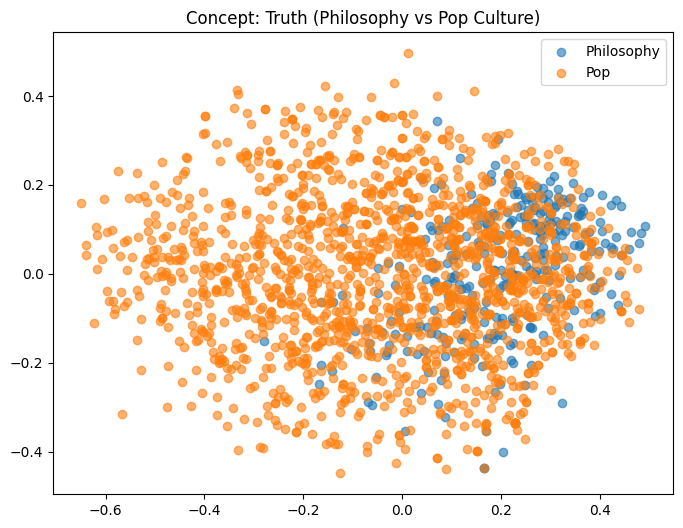

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine embeddings
all_embeddings = np.vstack([philo_embeddings, pop_embeddings])
labels = (["Philosophy"] * len(philo_embeddings)) + (["Pop"] * len(pop_embeddings))

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(8,6))
for label in set(labels):
    idxs = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(reduced[idxs,0], reduced[idxs,1], label=label, alpha=0.6)

plt.legend()
plt.title("Concept: Truth (Philosophy vs Pop Culture)")
plt.show()


##### Continuing with the concept of Truth first

In [6]:
import pandas as pd

# Load philosophy + pop culture data
philosophy_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\philosophy_texts\philosophy_texts_merged.csv')
pop_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\pop_texts\final_merged_all_comments.csv')

print("Philosophy shape:", philosophy_df.shape)
print("Pop shape:", pop_df.shape)


Philosophy shape: (16738, 9)
Pop shape: (104532, 19)


C:\Users\USER\AppData\Local\Temp\ipykernel_12224\2697154909.py:5: DtypeWarning: Columns (1,4,7,8,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  pop_df = pd.read_csv(r'C:\Users\USER\Desktop\Projects\philosophy_and_popculture\data\pop_texts\final_merged_all_comments.csv')


We'll filter the rows that mention the word "truth"

In [7]:
# Filter rows that contain "truth"
philosophy_truth = philosophy_df[philosophy_df['comment'].str.contains("truth", case=False, na=False)]
pop_truth = pop_df[pop_df['comment'].str.contains("truth", case=False, na=False)]

print("Philosophy truth samples:", philosophy_truth.shape)
print("Pop truth samples:", pop_truth.shape)

Philosophy truth samples: (300, 9)
Pop truth samples: (1524, 19)


Encode the embeddings

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode philosophy + pop truth subsets
philo_embeddings = model.encode(philosophy_truth['comment'].tolist())
pop_embeddings = model.encode(pop_truth['comment'].tolist())

Compare the similarities, their internal coherence and cross-domain divergence

In [9]:
from sentence_transformers import util
import numpy as np

# Philosophy vs Philosophy
philo_sim = util.cos_sim(philo_embeddings, philo_embeddings).mean().item()

# Pop vs Pop
pop_sim = util.cos_sim(pop_embeddings, pop_embeddings).mean().item()

# Cross (Philosophy vs Pop)
cross_sim = util.cos_sim(philo_embeddings, pop_embeddings).mean().item()

print("Philosophy internal similarity:", philo_sim)
print("Pop internal similarity:", pop_sim)
print("Cross similarity:", cross_sim)

Philosophy internal similarity: 0.3376542031764984
Pop internal similarity: 0.21762223541736603
Cross similarity: 0.2296181172132492


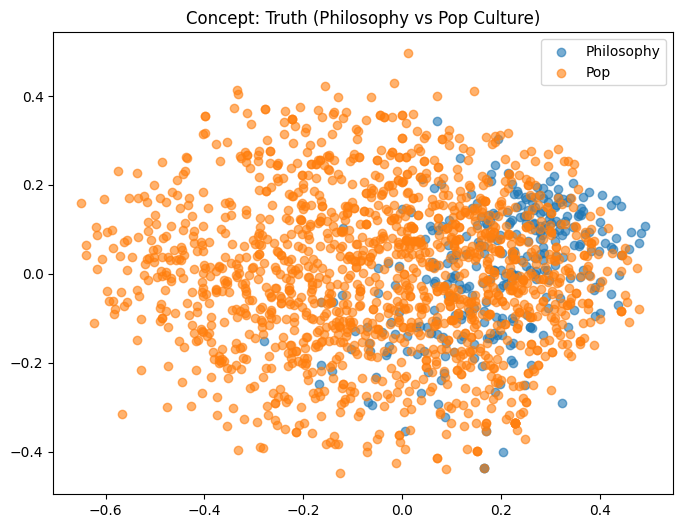

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine embeddings
all_embeddings = np.vstack([philo_embeddings, pop_embeddings])
labels = (["Philosophy"] * len(philo_embeddings)) + (["Pop"] * len(pop_embeddings))

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(8,6))
for label in set(labels):
    idxs = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(reduced[idxs,0], reduced[idxs,1], label=label, alpha=0.6)

plt.legend()
plt.title("Concept: Truth (Philosophy vs Pop Culture)")
plt.show()

In [11]:
from sentence_transformers import util

# Compare philosophy truth subset to pop truth subset
cosine_scores = util.cos_sim(philo_embeddings, pop_embeddings)

# Find top-k closest pairs
top_k = 5
pairs = []
for i in range(len(philo_embeddings)):
    for j in range(len(pop_embeddings)):
        pairs.append((cosine_scores[i][j].item(), i, j))

# Sort by similarity
pairs = sorted(pairs, key=lambda x: x[0], reverse=True)

print("\nTop closest Philosophy vs Pop sentences:")
for score, i, j in pairs[:top_k]:
    print(f"Philo: {philosophy_truth.iloc[i]['comment']}")
    print(f"Pop:   {pop_truth.iloc[j]['comment']}")
    print(f"Score: {score:.3f}")
    print()

print("\nMost different Philosophy vs Pop sentences:")
for score, i, j in pairs[-top_k:]:
    print(f"Philo: {philosophy_truth.iloc[i]['comment']}")
    print(f"Pop:   {pop_truth.iloc[j]['comment']}")
    print(f"Score: {score:.3f}")
    print()



Top closest Philosophy vs Pop sentences:
Philo: truth.
Pop:   Truth.
Score: 1.000

Philo: truth!
Pop:   Truth!
Score: 1.000

Philo: truth!
Pop:   Truth!
Score: 1.000

Philo: truth.
Pop:   Truth
Score: 0.844

Philo: truth.
Pop:   Truth
Score: 0.844


Most different Philosophy vs Pop sentences:
Philo: no! enemy to such statues of truth,
Pop:   I was fairly young when I lost my mother, I actually just turned 5 a few days before. Being young, I really had no idea what was really going on. But what I did know is that I was sad. For the next maybe 7 years I would get made fun of and teased for it. What really got me over it was when I realized there was no bringing back my mother. Music really helped, along with those around me. Realizing that you spent time with somebody you loved, has just been taken from you is hard to get around. Yeah that sounds a little weird. Me saying that you just have to deal with it and let it pass is too straightforward, but it’s the truth. At least for me it wa

In [12]:
# Internal similarity within philosophy
philo_scores = util.cos_sim(philo_embeddings, philo_embeddings)

pairs = []
for i in range(len(philo_embeddings)):
    for j in range(i+1, len(philo_embeddings)):  # avoid duplicate pairs
        pairs.append((philo_scores[i][j].item(), i, j))

pairs = sorted(pairs, key=lambda x: x[0], reverse=True)

print("\nTop closest Philosophy vs Philosophy sentences:")
for score, i, j in pairs[:5]:
    print(f"Philo A: {philosophy_truth.iloc[i]['comment']}")
    print(f"Philo B: {philosophy_truth.iloc[j]['comment']}")
    print(f"Score: {score:.3f}")
    print()

print("\nMost different Philosophy vs Philosophy sentences:")
for score, i, j in pairs[-5:]:
    print(f"Philo A: {philosophy_truth.iloc[i]['comment']}")
    print(f"Philo B: {philosophy_truth.iloc[j]['comment']}")
    print(f"Score: {score:.3f}")
    print()



Top closest Philosophy vs Philosophy sentences:
Philo A: that – the wooer of truth?
Philo B: that – the wooer of truth?
Score: 1.000

Philo A: truth!
Philo B: truth!
Score: 1.000

Philo A: hence, although truth and falsehood are properties of beliefs, they are
Philo B: thus although truth and falsehood are properties of beliefs, yet they are
Score: 0.977

Philo A: we may say that a truth is self-evident, in the first and most absolute sense, when we have
Philo B: we may say that a truth is self-evident, in the first and most absolute
Score: 0.966

Philo A: and footstep of my will: truly, my will to power walks with the feet of your will to truth!
Philo B: truly, my will to power walks with the feet of your will to truth!
Score: 0.918


Most different Philosophy vs Philosophy sentences:
Philo A: it may well seem that his scanty store of facts were the actual ground and source of the truth and
Philo B: seductive; and in truth! it will even thank you for overthrowing it, you
Score: -0.04

In [13]:
netsh interface set interface "Apple Mobile Device Ethernet" admin=disable
netsh interface set interface "Apple Mobile Device Ethernet" admin=enable

SyntaxError: invalid syntax (3476378246.py, line 1)

Let's quickly do a keyword context inspection of the word truth to see what we find

In [14]:
from collections import Counter
import re

def get_top_cooccurring_words(df, keyword="truth", top_n=20):
    # Combine all comments into one string
    text = " ".join(df['comment'].astype(str).tolist()).lower()
    
    # Split into tokens
    tokens = re.findall(r'\b\w+\b', text)
    
    # Find positions of the keyword
    positions = [i for i, w in enumerate(tokens) if w == keyword]
    
    # Collect words around the keyword
    context_words = []
    window = 3  # 3 words before and after
    for pos in positions:
        start = max(0, pos - window)
        end = min(len(tokens), pos + window + 1)
        context_words.extend(tokens[start:pos] + tokens[pos+1:end])
    
    # Count and show most common
    return Counter(context_words).most_common(top_n)

# Run for both datasets
philo_keywords = get_top_cooccurring_words(philosophy_truth)
pop_keywords = get_top_cooccurring_words(pop_truth)

print("Top words around 'truth' (Philosophy):")
print(philo_keywords)
print("\nTop words around 'truth' (Pop):")
print(pop_keywords)

Top words around 'truth' (Philosophy):
[('the', 117), ('of', 84), ('and', 54), ('is', 53), ('to', 38), ('in', 33), ('a', 28), ('that', 28), ('truth', 26), ('it', 19), ('for', 18), ('you', 18), ('not', 17), ('this', 17), ('falsehood', 17), ('i', 16), ('will', 13), ('your', 12), ('have', 12), ('or', 12)]

Top words around 'truth' (Pop):
[('the', 1125), ('is', 537), ('and', 338), ('of', 254), ('to', 248), ('i', 226), ('that', 221), ('a', 171), ('you', 168), ('truth', 148), ('it', 136), ('this', 121), ('in', 120), ('for', 118), ('s', 103), ('but', 97), ('not', 92), ('we', 78), ('about', 69), ('objective', 63)]


Here we see in Philosophy that:

Top nearby words include “falsehood,” “not,” “is,” “that,” “to,” “of,” etc.

→ These are abstract and logical connectors, often found in argumentation or definition-building (e.g. “Truth is not…”, “The nature of truth…”, “Truth and falsehood…”).

This shows philosophers tend to use truth in discursive, analytical contexts — exploring what truth is, its conditions, and in contrasts (truth vs falsehood).



While Pop culture:

Includes words like “we,” “about,” “objective,” “not,” “but,” “you,” “I.”

→ This reads as subjective and social framing — people are talking about truth in personal or communal terms (“your truth,” “we need truth,” “be real,” “truth is about honesty”).

Even the appearance of “objective” is interesting — it’s used, but likely in debate (“truth isn’t objective,” etc.), not in a technical sense.

🔹 Inference:
Philosophy treats truth as a concept to analyze.
Pop culture treats truth as a value or stance to express.
So you’re seeing ontological exploration vs identity expression.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Labels: 0 = Philosophy, 1 = Pop
X = np.vstack([philo_embeddings, pop_embeddings])
y = np.array([0]*len(philo_embeddings) + [1]*len(pop_embeddings))

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9260273972602739

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65        52
           1       0.92      1.00      0.96       313

    accuracy                           0.93       365
   macro avg       0.96      0.74      0.80       365
weighted avg       0.93      0.93      0.91       365



Using the simple logistic regression, we've been able to predict whether a text came from philosophy or pop culture with ~93% accuracy.

That’s very high for embeddings of a single concept word like “truth.”
It means the semantic neighborhood (the words and contexts surrounding “truth”) is systematically different across the two corpora.

High precision for Pop (class 1):
The model rarely mistakes pop texts for philosophy.

Lower recall for Philosophy (class 0):
Some philosophical uses of “truth” look linguistically similar to pop ones — likely those that simplify or moralize truth.

🔹 Inference:
There’s a strong, measurable semantic divergence between how truth appears in philosophical vs pop contexts.
Philosophers use truth in systematic, technical, definitional ways.
Pop culture uses truth in experiential, subjective, relational ways.

### Link these back to the earlier PCA plot

i happened to notice a left/right split in the scatter plot earlier and now it makes sense.

The model and co-occurrence stats confirm that those clusters aren’t random — they reflect semantic structure.

One side, the right cluster corresponds to truth as logical object;
the other, the left cluster corresponds to truth as personal or emotional stance.